In [ ]:
# === RANDOM FOREST REGRESSOR ===
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# For demonstration, we'll use the 'weight-height.csv' dataset you provided.
# If you use a different dataset with missing values or text, the preprocessing steps will be necessary.
try:
    df = pd.read_csv("weight-height.csv")
except FileNotFoundError:
    print("Please make sure 'weight-height.csv' is in the same directory.")
    # Creating a dummy dataframe if the file is not found
    data = {'Gender': ['Male','Male','Female','Female'],
            'Height': [73.8, 68.7, 64.5, 61.4],
            'Weight': [241.8, 162.3, 139.6, 126.2]}
    df = pd.DataFrame(data)


# === 1. DEFINE TARGET AND FEATURES ===
target = "Weight"
features = [col for col in df.columns if col != target]

# Display initial data info
print("--- Initial Data Head ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Optional: Visualize correlations for numeric features
numeric_df = df.select_dtypes(include=np.number)
if not numeric_df.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

# === 2. SPLIT DATA FIRST TO PREVENT DATA LEAKAGE ===
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# === 3. PREPROCESSING & ENCODING ===
# Note: These steps are templates. For 'weight-height.csv', they might not be needed,
# but they are crucial for datasets with mixed data types or missing values.

# Separate columns by data type
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

# Handle categorical features using one-hot encoding
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Align columns - crucial if test set is missing a category present in train set
X_train_final, X_test_final = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)


# === 4. TRAIN THE RANDOM FOREST MODEL ===
# RandomForest is an ensemble of Decision Trees. n_estimators is the number of trees.
# Note: We are using the unscaled data (X_train_final) as tree models don't require feature scaling.
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_final, y_train)


# === 5. MAKE PREDICTIONS AND EVALUATE ===
y_pred = model.predict(X_test_final)

print("\n--- Model Evaluation (Random Forest) ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")


🤖 Training the Random Forest Regressor...
✅ Model training complete!

--- Regression Metrics --- 📈
Mean Squared Error (MSE): 145.35
Root Mean Squared Error (RMSE): 12.06
Mean Absolute Error (MAE): 9.52
R-squared (R²): 0.8612


--- Data Head ---
   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   
3        33241  city_115                   0.789    NaN   
4          666  city_162                   0.767   Male   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enrollment        Graduate   
1   No relevent experience       no_enrollment        Graduate   
2   No relevent experience    Full time course        Graduate   
3   No relevent experience                 NaN        Graduate   
4  Has relevent experience       no_enrollment         Masters   

  major_discipline  experience company_size    company_type  training_hours  \
0             STEM        20.0          NaN             NaN            36.0   
1             STEM        15.0        50-99         Pvt Ltd            4

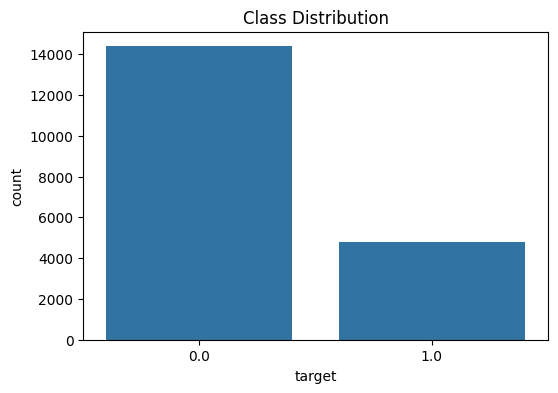

✅ Missing value imputation complete!
✅ Feature encoding complete!
✅ Model training complete!

--- Model Evaluation (Random Forest) ---
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      2877
         1.0       0.57      0.42      0.49       955

    accuracy                           0.78      3832
   macro avg       0.70      0.66      0.67      3832
weighted avg       0.76      0.78      0.77      3832

accuracy 0.7779227557411273
recall 0.5742857142857143
confusion_matrix [[2579  553]
 [ 298  402]]
classification_report               precision    recall  f1-score   support

         0.0       0.90      0.82      0.86      3132
         1.0       0.42      0.57      0.49       700

    accuracy                           0.78      3832
   macro avg       0.66      0.70      0.67      3832
weighted avg       0.81      0.78      0.79      3832



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,recall_score

# === 1. LOAD DATA ===

df = pd.read_csv("data_science_job.csv")


# === 2. INITIAL DATA ANALYSIS ===
print("--- Data Head ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())
target = "target"

# Drop rows where the target variable is missing, if any
df.dropna(subset=[target], inplace=True)

plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df)
plt.title("Class Distribution")
plt.show()

# === 3. SPLIT DATA ===
X = df.drop(target, axis=1)
y = df[target]
# Use stratify for classification problems to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# === 4. DATA PREPROCESSING (IMPUTE MISSING VALUES) ===
# Learn from train set, apply to both train and test to prevent data leakage
for col in X_train.columns:
    if X_train[col].dtypes == "object":
        mode_val = X_train[col].mode()[0]
        X_train[col] = X_train[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)
    else:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
print("✅ Missing value imputation complete!")

# === 5. ENCODE CATEGORICAL FEATURES ===
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_train_final, X_test_final = X_train_encoded.align(X_test_encoded, axis=1, fill_value=0, join="left")
print("✅ Feature encoding complete!")

# NOTE: Feature scaling (StandardScaler) is removed as it's not required for tree-based models.

# === 6. TRAIN THE RANDOM FOREST MODEL ===
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_final, y_train)
print("✅ Model training complete!")

# === 7. EVALUATE THE MODEL ===
y_pred = model.predict(X_test_final)

print("\n--- Model Evaluation (Random Forest) ---")

print(classification_report(y_test, y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("recall",recall_score(y_pred,y_test))
print("confusion_matrix",confusion_matrix(y_pred,y_test))
print("classification_report",classification_report(y_pred,y_test))